# ML Engineer — Final IMDb Sentiment Pipeline

This is the corrected ML-engineering workflow for the **IMDb review sentiment dataset**.

Input dataset: `compressed_data.csv`
Target: `sentiment`
Text: `review`

The `review_tokens_cleaned` column is not used as the model input because it is stored as serialized text/list data and caused character-level analysis in the earlier EDA.


## ML Engineer deliverables

This notebook covers:

1. Dataset/schema validation
2. Leakage-safe deduplication
3. Reproducible train/validation/test split
4. Consistent text preprocessing
5. TF-IDF
6. Logistic Regression / Linear SVM / Multinomial Naive Bayes comparison
7. Cross-validation on training data only
8. Hyperparameter tuning
9. Threshold selection on validation only
10. Final untouched-test evaluation
11. Confusion matrix and error analysis
12. Saving the model artifact
13. Application-ready prediction

**Not yet possible from the uploaded notebooks:** aspect-level models for taste, food quality, service, packaging, value, etc. because independent aspect labels are not present.

In [1]:
# 1. Imports
!pip -q install joblib

import os
import re
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, average_precision_score, brier_score_loss
)

RANDOM_STATE = 42

In [2]:
# 2. Upload the CORRECT project dataset
uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))

Saving compressed_data.csv to compressed_data.csv
Uploaded: ['compressed_data.csv']


In [3]:
# 3. Load CSV
csv_files = [f for f in uploaded.keys() if f.lower().endswith(".csv")]
if not csv_files:
    raise ValueError("Please upload a CSV dataset.")

DATA_FILE = csv_files[0]
df = pd.read_csv(DATA_FILE)

print("File:", DATA_FILE)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

File: compressed_data.csv
Shape: (49581, 3)
Columns: ['review', 'sentiment', 'review_tokens_cleaned']


,review,sentiment,review_tokens_cleaned
0,if you enjoy the original snl cast and shows t...,0,"['enjoy', 'original', 'snl', 'cast', 'shows', ..."
1,a very tired looking burt reynolds plays a mer...,0,"['tired', 'looking', 'burt', 'reynolds', 'play..."
2,first of all if your a fan of the comic well y...,0,"['first', 'fan', 'comic', 'well', 'youll', 'di..."
3,it was all over with the slashers around 88 so...,0,"['slashers', 'around', '88', 'time', 'cheesy',..."
4,i really tried to like this movie it deals wit...,0,"['really', 'tried', 'like', 'movie', 'deals', ..."


In [4]:
# 4. Configure the project columns
TEXT_COLUMN = "review"

# Use an independently labelled sentiment column if you have one.
TARGET_COLUMN = "sentiment"

# Optional star-rating column. Leave None if not present.
RATING_COLUMN = None

print("TEXT_COLUMN =", TEXT_COLUMN)
print("TARGET_COLUMN =", TARGET_COLUMN)
print("RATING_COLUMN =", RATING_COLUMN)

TEXT_COLUMN = review
TARGET_COLUMN = sentiment
RATING_COLUMN = None


In [5]:
# 5. Validate schema
if TEXT_COLUMN not in df.columns:
    raise ValueError(f"Missing '{TEXT_COLUMN}'. Available: {df.columns.tolist()}")

if TARGET_COLUMN is not None and TARGET_COLUMN not in df.columns:
    raise ValueError(f"Missing '{TARGET_COLUMN}'. Available: {df.columns.tolist()}")

if RATING_COLUMN is not None and RATING_COLUMN not in df.columns:
    raise ValueError(f"Missing '{RATING_COLUMN}'. Available: {df.columns.tolist()}")

print("Schema validation passed.")

Schema validation passed.


In [6]:
# 6. Data-quality audit
print("Missing values:")
display(df.isnull().sum())

print("Duplicate complete rows:", df.duplicated().sum())
print("Duplicate reviews:", df[TEXT_COLUMN].astype(str).duplicated().sum())

if TARGET_COLUMN is not None:
    print("\nTarget distribution:")
    display(df[TARGET_COLUMN].value_counts(dropna=False))

Missing values:


,0
review,0
sentiment,0
review_tokens_cleaned,0


Duplicate complete rows: 0
Duplicate reviews: 0

Target distribution:


,count
sentiment,
1,24884
0,24697


## Text preprocessing

The previous preprocessing notebook removes stopwords. That is risky for sentiment because words such as `not`, `no`, and `never` can change the meaning.

The final pipeline below preserves negation.

In [7]:
# 7. Create a reusable preprocessing module
module_code = r'''
import re

def clean_text(text):
    text = "" if text is None else str(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = text.lower()
    text = text.replace("can't", "can not")
    text = text.replace("won't", "will not")
    text = text.replace("n't", " not")
    text = re.sub(r"[^a-z0-9'\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text
'''
with open("text_preprocessor.py", "w", encoding="utf-8") as f:
    f.write(module_code)

from text_preprocessor import clean_text
print("Preprocessor created.")

Preprocessor created.


In [8]:
# 8. Clean + deduplicate BEFORE splitting
df = df.copy()
df["_clean_review"] = df[TEXT_COLUMN].fillna("").map(clean_text)

before = len(df)
df = df[df["_clean_review"].str.len() > 0].copy()

df = df.drop_duplicates(subset=["_clean_review"]).reset_index(drop=True)

print("Empty reviews removed:", before - len(df))
print("Rows after deduplication:", len(df))
print("Remaining duplicate cleaned reviews:", df["_clean_review"].duplicated().sum())

Empty reviews removed: 1
Rows after deduplication: 49580
Remaining duplicate cleaned reviews: 0


In [9]:
# 9. Validate binary target
if TARGET_COLUMN is None:
    raise ValueError(
        "An independent sentiment label is required for supervised training. "
        "Do not create the final research target from the same rating you are trying to evaluate."
    )

df["_target"] = df[TARGET_COLUMN]
df = df.dropna(subset=["_target"]).copy()

if df["_target"].nunique() != 2:
    raise ValueError(
        f"This notebook expects binary sentiment. Found: {df['_target'].unique().tolist()}"
    )

print("Classes:", df["_target"].unique().tolist())
display(df["_target"].value_counts())

Classes: [0, 1]


,count
_target,
1,24883
0,24697


## Train / validation / test split

- Train: model fitting, CV and tuning
- Validation: threshold selection
- Test: final evaluation only

This fixes the earlier problem where the test set was used to choose a threshold.

In [10]:
# 10. 80/10/10 stratified split
X = df["_clean_review"]
y = df["_target"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 39664
Validation: 4958
Test: 4958


In [11]:
# 11. Verify split proportions
split_summary = pd.DataFrame({
    "train": y_train.value_counts(normalize=True),
    "validation": y_val.value_counts(normalize=True),
    "test": y_test.value_counts(normalize=True)
}).sort_index()

display(split_summary)

,train,validation,test
_target,,,
0,0.498134,0.497983,0.498185
1,0.501866,0.502017,0.501815


## Model comparison

TF-IDF is inside each Pipeline. This prevents TF-IDF from being fitted on validation folds before cross-validation.

This is the main correction to the earlier Data Scientist CV implementation.

In [12]:
# 12. Candidate models
def make_tfidf():
    return TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.98,
        max_features=20000,
        sublinear_tf=True,
        lowercase=False
    )

models = {
    "Logistic Regression": Pipeline([
        ("tfidf", make_tfidf()),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    "Linear SVM": Pipeline([
        ("tfidf", make_tfidf()),
        ("model", LinearSVC(max_iter=5000, random_state=RANDOM_STATE))
    ]),
    "Multinomial Naive Bayes": Pipeline([
        ("tfidf", make_tfidf()),
        ("model", MultinomialNB())
    ])
}

In [13]:
# 13. 5-fold CV on TRAINING DATA ONLY
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rows = []
for name, pipe in models.items():
    scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring={
            "accuracy": "accuracy",
            "precision_macro": "precision_macro",
            "recall_macro": "recall_macro",
            "f1_macro": "f1_macro"
        },
        n_jobs=-1
    )
    rows.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision_macro"].mean(),
        "CV Recall": scores["test_recall_macro"].mean(),
        "CV Macro F1": scores["test_f1_macro"].mean()
    })

cv_results = pd.DataFrame(rows).sort_values("CV Macro F1", ascending=False)
display(cv_results)

,Model,CV Accuracy,CV Precision,CV Recall,CV Macro F1
0,Logistic Regression,0.902506,0.902676,0.902469,0.902489
1,Linear SVM,0.898750,0.898800,0.898731,0.898742
2,Multinomial Naive Bayes,0.875479,0.875562,0.875454,0.875466


## Hyperparameter tuning

Logistic Regression is used as the probability-producing candidate because it supports `predict_proba`. The final model should still be selected from the actual IMDb dataset's validation/CV results.

In [14]:
# 14. Tune Logistic Regression
lr_pipeline = Pipeline([
    ("tfidf", make_tfidf()),
    ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))
])

param_grid = {
    "tfidf__max_features": [10000, 20000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "model__C": [0.1, 1.0, 3.0, 10.0]
}

grid = GridSearchCV(
    lr_pipeline, param_grid, cv=cv,
    scoring="f1_macro", n_jobs=-1, verbose=1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV Macro F1:", grid.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'model__C': 3.0, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2)}
Best CV Macro F1: 0.9051894422853206


In [15]:
# 15. Fit selected model on TRAIN only
final_model = grid.best_estimator_
final_model.fit(X_train, y_train)

print("Classes:", final_model.classes_)

Classes: [0 1]


## Threshold selection

Select the threshold on the validation set, not the test set.

If the project later defines real false-positive/false-negative business costs, those costs should come from the project requirements rather than arbitrary numbers.

In [16]:
# 16. Select threshold using validation Macro F1
val_prob = final_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)
rows = []

for t in thresholds:
    pred = (val_prob >= t).astype(int)
    rows.append({
        "threshold": t,
        "macro_f1": f1_score(y_val, pred, average="macro"),
        "accuracy": accuracy_score(y_val, pred),
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0)
    })

threshold_results = pd.DataFrame(rows)
best_threshold = float(
    threshold_results.loc[threshold_results["macro_f1"].idxmax(), "threshold"]
)

print("Validation-selected threshold:", round(best_threshold, 2))
display(threshold_results.sort_values("macro_f1", ascending=False).head(10))

Validation-selected threshold: 0.55


,threshold,macro_f1,accuracy,precision,recall
45,0.55,0.911052,0.911053,0.912903,0.909602
47,0.57,0.910849,0.910851,0.918609,0.902370
46,0.56,0.910649,0.910649,0.914842,0.906388
36,0.46,0.910347,0.910448,0.888046,0.940137
37,0.47,0.910158,0.910246,0.889482,0.937726
48,0.58,0.910038,0.910044,0.920890,0.897951
43,0.53,0.910034,0.910044,0.905196,0.916834
44,0.54,0.909638,0.909641,0.908363,0.912013
42,0.52,0.909622,0.909641,0.901614,0.920450
40,0.50,0.909604,0.909641,0.897236,0.926075


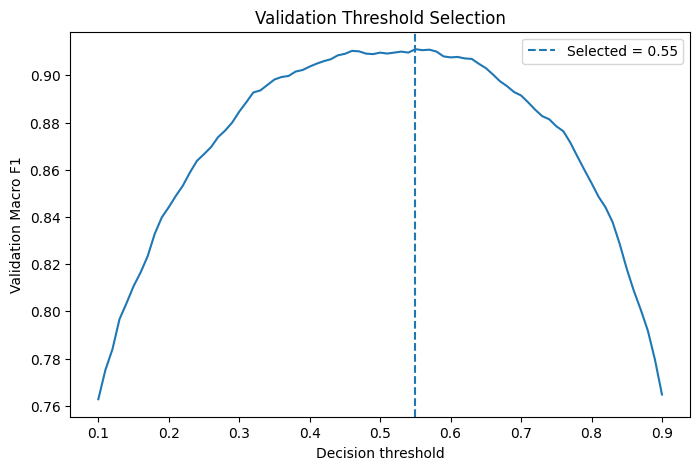

In [17]:
# 17. Plot threshold selection
plt.figure(figsize=(8, 5))
plt.plot(threshold_results["threshold"], threshold_results["macro_f1"])
plt.axvline(best_threshold, linestyle="--", label=f"Selected = {best_threshold:.2f}")
plt.xlabel("Decision threshold")
plt.ylabel("Validation Macro F1")
plt.title("Validation Threshold Selection")
plt.legend()
plt.show()

## Final test evaluation

The test set is now evaluated once using the locked model and locked threshold.

In [18]:
# 18. Final test metrics
test_prob = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= best_threshold).astype(int)

print(classification_report(y_test, test_pred, digits=4))

final_metrics = {
    "accuracy": float(accuracy_score(y_test, test_pred)),
    "precision_macro": float(precision_score(y_test, test_pred, average="macro", zero_division=0)),
    "recall_macro": float(recall_score(y_test, test_pred, average="macro", zero_division=0)),
    "f1_macro": float(f1_score(y_test, test_pred, average="macro")),
    "roc_auc": float(roc_auc_score(y_test, test_prob)),
    "average_precision": float(average_precision_score(y_test, test_prob)),
    "brier_score": float(brier_score_loss(y_test, test_prob)),
    "decision_threshold": best_threshold
}

print("\nFinal test metrics:")
for k, v in final_metrics.items():
    print(f"{k}: {v:.4f}")

              precision    recall  f1-score   support

           0     0.9072    0.9146    0.9109      2470
           1     0.9145    0.9072    0.9108      2488

    accuracy                         0.9109      4958
   macro avg     0.9109    0.9109    0.9109      4958
weighted avg     0.9109    0.9109    0.9109      4958


Final test metrics:
accuracy: 0.9109
precision_macro: 0.9109
recall_macro: 0.9109
f1_macro: 0.9109
roc_auc: 0.9689
average_precision: 0.9674
brier_score: 0.0703
decision_threshold: 0.5500


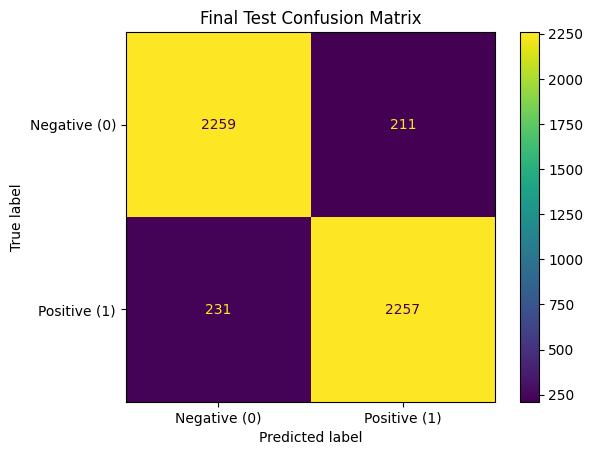

TN: 2259 FP: 211 FN: 231 TP: 2257


In [19]:
# 19. Confusion matrix
cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative (0)", "Positive (1)"]
)
disp.plot(values_format="d")
plt.title("Final Test Confusion Matrix")
plt.show()

tn, fp, fn, tp = cm.ravel()
print("TN:", tn, "FP:", fp, "FN:", fn, "TP:", tp)

## Error analysis

Inspect false positives and false negatives. For food reviews, pay attention to:
- mixed sentiment
- sarcasm
- aspect-specific sentiment
- slang
- ambiguous language
- reviews that praise food but criticize service, or vice versa

In [20]:
# 20. Error analysis
error_df = pd.DataFrame({
    "review": X_test.values,
    "actual": y_test.values,
    "predicted": test_pred,
    "positive_probability": test_prob
})

error_df["error_type"] = np.where(
    (error_df["actual"] == 0) & (error_df["predicted"] == 1), "False Positive",
    np.where((error_df["actual"] == 1) & (error_df["predicted"] == 0), "False Negative", "Correct")
)

false_positives = error_df[error_df["error_type"] == "False Positive"].sort_values("positive_probability", ascending=False)
false_negatives = error_df[error_df["error_type"] == "False Negative"].sort_values("positive_probability", ascending=True)

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))
print("\nTop false positives:")
display(false_positives.head(10))
print("\nTop false negatives:")
display(false_negatives.head(10))


False positives: 211
False negatives: 231

Top false positives:


,review,actual,predicted,positive_probability,error_type
1112,i enjoyed the beautiful scenery in this movie ...,0,1,0.995627,False Positive
4025,this movie was pure genius john waters is bril...,0,1,0.994876,False Positive
3731,i love the episode where jim becomes the green...,0,1,0.982906,False Positive
3340,this is a fact that this is the 1st saudi feat...,0,1,0.971035,False Positive
2311,this is one entertaining flick i suggest you r...,0,1,0.958624,False Positive
172,this was a very nice concert by the one and on...,0,1,0.958227,False Positive
2509,helen of troy follows the story of helen and t...,0,1,0.957701,False Positive
803,i saw winnies heffalump a couple of days ago a...,0,1,0.955416,False Positive
1142,boston legal has turned its tail and is headed...,0,1,0.954528,False Positive
363,going into the movie with the right expectatio...,0,1,0.936866,False Positive



Top false negatives:


,review,actual,predicted,positive_probability,error_type
1538,if the creators of this film had made any atte...,1,0,0.010083,False Negative
2919,i cant believe i missed this one made in 1970 ...,1,0,0.015264,False Negative
1113,this show has all the typical characters in a ...,1,0,0.037290,False Negative
556,well wellroeg touched a bit of a nerve there d...,1,0,0.045216,False Negative
4277,im a bit conflicted over this the show is on o...,1,0,0.046889,False Negative
4931,e elias merhiges existentialist experiment in ...,1,0,0.047311,False Negative
717,child sexploitation is one of the most serious...,1,0,0.070384,False Negative
3916,this allbutignored masterpiece is about the mo...,1,0,0.072300,False Negative
2319,i remember this movie getting a lot of flak fr...,1,0,0.073455,False Negative
2358,black tar cant be snorted theres a documentary...,1,0,0.074920,False Negative


In [21]:
# 21. Application-ready prediction tests
def predict_review(review):
    cleaned = clean_text(review)
    p_positive = float(final_model.predict_proba([cleaned])[0, 1])
    pred = int(p_positive >= best_threshold)
    return {
        "prediction": pred,
        "label": "Positive" if pred == 1 else "Negative",
        "probability_positive": round(p_positive, 4),
        "threshold": round(float(best_threshold), 4)
    }

examples = [
    "This movie was absolutely fantastic. I loved every minute of it.",
    "Terrible movie. A complete waste of time and money.",
    "The acting was good, but the story was disappointing and boring."
]

for review in examples:
    print(review)
    print(predict_review(review))
    print()


This movie was absolutely fantastic. I loved every minute of it.
{'prediction': 1, 'label': 'Positive', 'probability_positive': 0.8946, 'threshold': 0.55}

Terrible movie. A complete waste of time and money.
{'prediction': 0, 'label': 'Negative', 'probability_positive': 0.0002, 'threshold': 0.55}

The acting was good, but the story was disappointing and boring.
{'prediction': 0, 'label': 'Negative', 'probability_positive': 0.0055, 'threshold': 0.55}



In [22]:
# 22. Save production artifacts
ARTIFACT_DIR = "ml_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

joblib.dump(final_model, f"{ARTIFACT_DIR}/sentiment_pipeline.joblib")

with open(f"{ARTIFACT_DIR}/threshold.json", "w") as f:
    json.dump({"threshold": float(best_threshold)}, f, indent=2)

with open(f"{ARTIFACT_DIR}/metrics.json", "w") as f:
    json.dump({k: float(v) for k, v in final_metrics.items()}, f, indent=2)

feature_names = final_model.named_steps["tfidf"].get_feature_names_out()
np.save(f"{ARTIFACT_DIR}/tfidf_feature_names.npy", feature_names)

false_positives.head(50).to_csv(f"{ARTIFACT_DIR}/false_positives_top50.csv", index=False)
false_negatives.head(50).to_csv(f"{ARTIFACT_DIR}/false_negatives_top50.csv", index=False)
error_df.to_csv(f"{ARTIFACT_DIR}/test_predictions.csv", index=False)

with open(f"{ARTIFACT_DIR}/requirements.txt", "w") as f:
    f.write("numpy\npandas\nscikit-learn\njoblib\n")

print("Artifacts:")
for name in sorted(os.listdir(ARTIFACT_DIR)):
    print(" -", name)


Artifacts:
 - false_negatives_top50.csv
 - false_positives_top50.csv
 - metrics.json
 - requirements.txt
 - sentiment_pipeline.joblib
 - test_predictions.csv
 - tfidf_feature_names.npy
 - threshold.json


In [23]:
# 23. Backend handoff specification
handoff = {
    "model_file": "sentiment_pipeline.joblib",
    "threshold_file": "threshold.json",
    "input": {"review": "string"},
    "output": {
        "prediction": "0 or 1",
        "label": "Negative or Positive",
        "probability_positive": "float between 0 and 1",
        "threshold": "float"
    },
    "classes": {"0": "Negative", "1": "Positive"},
    "decision_rule": "Positive when probability_positive >= threshold; otherwise Negative."
}
with open(f"{ARTIFACT_DIR}/backend_handoff.json", "w") as f:
    json.dump(handoff, f, indent=2)
print(json.dumps(handoff, indent=2))


{
  "model_file": "sentiment_pipeline.joblib",
  "threshold_file": "threshold.json",
  "input": {
    "review": "string"
  },
  "output": {
    "prediction": "0 or 1",
    "label": "Negative or Positive",
    "probability_positive": "float between 0 and 1",
    "threshold": "float"
  },
  "classes": {
    "0": "Negative",
    "1": "Positive"
  },
  "decision_rule": "Positive when probability_positive >= threshold; otherwise Negative."
}


# Final ML Engineer checklist

- [ ] Correct IMDb dataset used
- [ ] No duplicate reviews before splitting
- [ ] No train/test leakage
- [ ] One consistent preprocessing path
- [ ] TF-IDF inside Pipeline/CV
- [ ] Candidate models compared on the correct dataset
- [ ] Hyperparameters tuned on training/CV only
- [ ] Threshold selected on validation only
- [ ] Test set evaluated once
- [ ] False positives/negatives inspected
- [ ] Model + threshold + metrics saved
- [ ] Prediction function tested on unseen reviews
- [ ] Aspect-level ML added only after independent aspect labels are available

## Research note

If the research question is whether star ratings represent specific aspect factors, do not create the ML target from the same star rating and then treat the model as independent evidence about that rating.

A stronger design is:

**Review text → independent sentiment/aspect labels → ML model**

separately from:

**Star rating → rating analysis**

Then compare the two.